In [69]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import seaborn as sns

%matplotlib inline

In [70]:
df = pd.read_csv("churn.csv")

In [71]:
df.head().T

,0,1,2,3,4
customerID,7590-VHVEG,5575-GNVDE,3668-QPYBK,7795-CFOCW,9237-HQITU
gender,Female,Male,Male,Male,Female
SeniorCitizen,0,0,0,0,0
Partner,Yes,No,No,No,No
Dependents,No,No,No,No,No
tenure,1,34,2,45,2
PhoneService,No,Yes,Yes,No,Yes
MultipleLines,No phone service,No,No,No phone service,No
InternetService,DSL,DSL,DSL,DSL,Fiber optic
OnlineSecurity,No,Yes,Yes,Yes,No


In [72]:
df.columns = df.columns.str.lower().str.replace(" ", "_")

df.head().T

,0,1,2,3,4
customerid,7590-VHVEG,5575-GNVDE,3668-QPYBK,7795-CFOCW,9237-HQITU
gender,Female,Male,Male,Male,Female
seniorcitizen,0,0,0,0,0
partner,Yes,No,No,No,No
dependents,No,No,No,No,No
tenure,1,34,2,45,2
phoneservice,No,Yes,Yes,No,Yes
multiplelines,No phone service,No,No,No phone service,No
internetservice,DSL,DSL,DSL,DSL,Fiber optic
onlinesecurity,No,Yes,Yes,Yes,No


In [73]:
df.dtypes

customerid              str
gender                  str
seniorcitizen         int64
partner                 str
dependents              str
tenure                int64
phoneservice            str
multiplelines           str
internetservice         str
onlinesecurity          str
onlinebackup            str
deviceprotection        str
techsupport             str
streamingtv             str
streamingmovies         str
contract                str
paperlessbilling        str
paymentmethod           str
monthlycharges      float64
totalcharges            str
churn                   str
dtype: object

In [74]:
categorical_columns = [
    column for column in df.columns if df[column].dtype == "str"
]

for col in categorical_columns:
    df[col] = df[col].str.lower().str.replace(" ", "_")
    
df.head().T

,0,1,2,3,4
customerid,7590-vhveg,5575-gnvde,3668-qpybk,7795-cfocw,9237-hqitu
gender,female,male,male,male,female
seniorcitizen,0,0,0,0,0
partner,yes,no,no,no,no
dependents,no,no,no,no,no
tenure,1,34,2,45,2
phoneservice,no,yes,yes,no,yes
multiplelines,no_phone_service,no,no,no_phone_service,no
internetservice,dsl,dsl,dsl,dsl,fiber_optic
onlinesecurity,no,yes,yes,yes,no


In [75]:
df.dtypes

customerid              str
gender                  str
seniorcitizen         int64
partner                 str
dependents              str
tenure                int64
phoneservice            str
multiplelines           str
internetservice         str
onlinesecurity          str
onlinebackup            str
deviceprotection        str
techsupport             str
streamingtv             str
streamingmovies         str
contract                str
paperlessbilling        str
paymentmethod           str
monthlycharges      float64
totalcharges            str
churn                   str
dtype: object

In [76]:
tc = pd.to_numeric(df['totalcharges'], errors="coerce")

In [77]:
df.totalcharges = pd.to_numeric(df.totalcharges, errors="coerce")

In [78]:
df.totalcharges = df.totalcharges.fillna(0)

In [79]:
df[tc.isnull()][['customerid', 'totalcharges']]

,customerid,totalcharges
488,4472-lvygi,0.0
753,3115-czmzd,0.0
936,5709-lvoeq,0.0
1082,4367-nuyao,0.0
1340,1371-dwpaz,0.0
3331,7644-omvmy,0.0
3826,3213-vvolg,0.0
4380,2520-sgtta,0.0
5218,2923-arzlg,0.0
6670,4075-wkniu,0.0


In [80]:
df.churn = (df.churn == 'yes').astype(int)

In [81]:
df.head()

,customerid,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,onlinesecurity,...,deviceprotection,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,monthlycharges,totalcharges,churn
0,7590-vhveg,female,0,yes,no,1,no,no_phone_service,dsl,no,...,no,no,no,no,month-to-month,yes,electronic_check,29.85,29.85,0
1,5575-gnvde,male,0,no,no,34,yes,no,dsl,yes,...,yes,no,no,no,one_year,no,mailed_check,56.95,1889.50,0
2,3668-qpybk,male,0,no,no,2,yes,no,dsl,yes,...,no,no,no,no,month-to-month,yes,mailed_check,53.85,108.15,1
3,7795-cfocw,male,0,no,no,45,no,no_phone_service,dsl,yes,...,yes,yes,no,no,one_year,no,bank_transfer_(automatic),42.30,1840.75,0
4,9237-hqitu,female,0,no,no,2,yes,no,fiber_optic,no,...,no,no,no,no,month-to-month,yes,electronic_check,70.70,151.65,1


### Spliting Datasets

In [82]:
from sklearn.model_selection import train_test_split

In [83]:
df_full_train, df_test = train_test_split(df, test_size=0.2, random_state=42)

In [84]:
df_train, df_val = train_test_split(df_full_train, test_size=0.25, random_state=42)

In [85]:
len(df_train), len(df_val), len(df_test)

(4225, 1409, 1409)

In [86]:
df_full_train = df_full_train.reset_index(drop=True)

df_train: pd.DataFrame = df_train.reset_index(drop=True)
df_val: pd.DataFrame = df_val.reset_index(drop=True)
df_test: pd.DataFrame = df_test.reset_index(drop=True)

In [87]:
y_train = df_train.churn.values
y_val = df_val.churn.values
y_test = df_test.churn.values

In [88]:
del df_train['churn']
del df_val['churn']
del df_test['churn']

### EDA (Explotary Data Analysis)

In [89]:
df_full_train.isnull().sum()

customerid          0
gender              0
seniorcitizen       0
partner             0
dependents          0
tenure              0
phoneservice        0
multiplelines       0
internetservice     0
onlinesecurity      0
onlinebackup        0
deviceprotection    0
techsupport         0
streamingtv         0
streamingmovies     0
contract            0
paperlessbilling    0
paymentmethod       0
monthlycharges      0
totalcharges        0
churn               0
dtype: int64

In [90]:
df_full_train.churn.value_counts(normalize=True)

churn
0    0.734469
1    0.265531
Name: proportion, dtype: float64

In [91]:
global_churn_rate = df_full_train.churn.mean()
round(global_churn_rate, 2)

np.float64(0.27)

In [92]:
df_full_train.columns

Index(['customerid', 'gender', 'seniorcitizen', 'partner', 'dependents',
       'tenure', 'phoneservice', 'multiplelines', 'internetservice',
       'onlinesecurity', 'onlinebackup', 'deviceprotection', 'techsupport',
       'streamingtv', 'streamingmovies', 'contract', 'paperlessbilling',
       'paymentmethod', 'monthlycharges', 'totalcharges', 'churn'],
      dtype='str')

In [93]:
numerical = [
       'tenure', 
       'monthlycharges', 
       'totalcharges'
]

categorical = [
       'gender', 
       'seniorcitizen', 
       'partner', 
       'dependents', 
       'phoneservice', 
       'multiplelines', 
       'internetservice',
       'onlinesecurity', 
       'onlinebackup', 
       'deviceprotection', 
       'techsupport',
       'streamingtv', 
       'streamingmovies', 
       'contract', 
       'paperlessbilling',
       'paymentmethod'
]

In [94]:
df_full_train[categorical].nunique()

gender              2
seniorcitizen       2
partner             2
dependents          2
phoneservice        2
multiplelines       3
internetservice     3
onlinesecurity      3
onlinebackup        3
deviceprotection    3
techsupport         3
streamingtv         3
streamingmovies     3
contract            3
paperlessbilling    2
paymentmethod       4
dtype: int64

### Feature Importance

In [95]:
df_group = df_full_train.groupby("gender").churn.agg(['mean', 'count'])

df_group['risk'] = df_group['mean'] / global_churn_rate
df_group['difference'] = df_group['mean'] - global_churn_rate

df_group

,mean,count,risk,difference
gender,,,,
female,0.270841,2747,1.019998,0.005310
male,0.260478,2887,0.980971,-0.005053


In [96]:
from IPython.display import display

In [97]:
for column in categorical:

    df_group = df_full_train.groupby(column).churn.agg(['mean', 'count'])

    df_group['risk'] = df_group['mean'] / global_churn_rate
    df_group['difference'] = df_group['mean'] - global_churn_rate

    display(df_group)
    print()

,mean,count,risk,difference
gender,,,,
female,0.270841,2747,1.019998,0.005310
male,0.260478,2887,0.980971,-0.005053


,mean,count,risk,difference
seniorcitizen,,,,
0,0.237098,4728,0.892922,-0.028433
1,0.413907,906,1.558793,0.148377


,mean,count,risk,difference
partner,,,,
no,0.326446,2904,1.229411,0.060916
yes,0.200733,2730,0.755968,-0.064798


,mean,count,risk,difference
dependents,,,,
no,0.312326,3951,1.176233,0.046795
yes,0.155674,1683,0.586276,-0.109856


,mean,count,risk,difference
phoneservice,,,,
no,0.253623,552,0.955156,-0.011908
yes,0.266824,5082,1.004871,0.001293


,mean,count,risk,difference
multiplelines,,,,
no,0.251397,2685,0.946771,-0.014134
no_phone_service,0.253623,552,0.955156,-0.011908
yes,0.284105,2397,1.069952,0.018574


,mean,count,risk,difference
internetservice,,,,
dsl,0.191851,1939,0.722521,-0.073679
fiber_optic,0.415558,2481,1.565010,0.150028
no,0.076606,1214,0.288502,-0.188924


,mean,count,risk,difference
onlinesecurity,,,,
no,0.416014,2810,1.566727,0.150484
no_internet_service,0.076606,1214,0.288502,-0.188924
yes,0.145342,1610,0.547363,-0.120189


,mean,count,risk,difference
onlinebackup,,,,
no,0.398693,2448,1.501494,0.133162
no_internet_service,0.076606,1214,0.288502,-0.188924
yes,0.216531,1972,0.815467,-0.048999


,mean,count,risk,difference
deviceprotection,,,,
no,0.387706,2489,1.460117,0.122175
no_internet_service,0.076606,1214,0.288502,-0.188924
yes,0.226825,1931,0.854234,-0.038705


,mean,count,risk,difference
techsupport,,,,
no,0.413472,2791,1.557153,0.147941
no_internet_service,0.076606,1214,0.288502,-0.188924
yes,0.152855,1629,0.575657,-0.112676


,mean,count,risk,difference
streamingtv,,,,
no,0.335418,2239,1.263197,0.069887
no_internet_service,0.076606,1214,0.288502,-0.188924
yes,0.298945,2181,1.125841,0.033415


,mean,count,risk,difference
streamingmovies,,,,
no,0.333333,2223,1.255348,0.067803
no_internet_service,0.076606,1214,0.288502,-0.188924
yes,0.301320,2197,1.134784,0.035789


,mean,count,risk,difference
contract,,,,
month-to-month,0.426533,3083,1.606340,0.161002
one_year,0.117987,1212,0.444343,-0.147544
two_year,0.028379,1339,0.106878,-0.237151


,mean,count,risk,difference
paperlessbilling,,,,
no,0.16414,2309,0.618159,-0.101390
yes,0.33594,3325,1.265164,0.070409


,mean,count,risk,difference
paymentmethod,,,,
bank_transfer_(automatic),0.174475,1238,0.657080,-0.091056
credit_card_(automatic),0.152404,1227,0.573961,-0.113126
electronic_check,0.449921,1887,1.694420,0.184390
mailed_check,0.190328,1282,0.716782,-0.075203


### Feature Importance: Mutal Information

In [98]:
from sklearn.metrics import mutual_info_score

In [99]:
sorted_dict = {}

for column in categorical:
    
    mutual_in_score = mutual_info_score(df_full_train.churn, df_full_train[column])
    sorted_dict[column] = mutual_in_score


sorted_dict = sorted(sorted_dict.items(), key=lambda x: x[1], reverse=True)

for key, value in sorted_dict:
    print(f"{key}: {value:.2f}")

contract: 0.10
onlinesecurity: 0.06
techsupport: 0.06
internetservice: 0.05
onlinebackup: 0.05
paymentmethod: 0.04
deviceprotection: 0.04
streamingtv: 0.03
streamingmovies: 0.03
paperlessbilling: 0.02
dependents: 0.01
partner: 0.01
seniorcitizen: 0.01
multiplelines: 0.00
gender: 0.00
phoneservice: 0.00


### Feature Importance: Correlation 

In [100]:
df_full_train[numerical].corrwith(df_full_train.churn)

tenure           -0.344925
monthlycharges    0.188574
totalcharges     -0.193370
dtype: float64

In [101]:
df_full_train[df_full_train.tenure <= 2].churn.mean()

np.float64(0.5863636363636363)

In [102]:
df_full_train[(df_full_train.tenure > 2) & (df_full_train.tenure <= 12)].churn.mean()

np.float64(0.4064814814814815)

In [103]:
df_full_train[df_full_train.tenure > 12].churn.mean()

np.float64(0.17205957883923986)

### One-hot Encoding

In [104]:
from sklearn.feature_extraction import DictVectorizer

In [105]:
dv = DictVectorizer(sparse=False)

train_dict = df_train[categorical + numerical].to_dict('records')
X_train = dv.fit_transform(train_dict)

val_dict = df_val[categorical + numerical].to_dict('records')
X_val = dv.transform(val_dict)

### Logistic Regression

In [106]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

In [107]:
w0 = 0
w = np.zeros(X_train.shape[1])
def linear_regression(xi):
    result = w0
    for j in range(len(xi)):
        result += w[j] * xi[j]
    return result

In [108]:
def logistic_regression(xi):
    return sigmoid(linear_regression(xi))

In [109]:
from sklearn.linear_model import LinearRegression, LogisticRegression

In [110]:
model = LogisticRegression()

model.fit(X_train, y_train)

/home/asilbek/Desktop/datatalks/venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [111]:
model.intercept_[0] # bias

np.float64(-0.12875819563844587)

In [112]:
model.coef_[0].round(3) # weights

array([ 0.55 , -0.207, -0.47 , -0.052, -0.075,  0.035, -0.114, -0.048,
        0.027, -0.154, -0.305,  0.293, -0.114,  0.002, -0.215,  0.123,
       -0.036,  0.088, -0.114, -0.101,  0.238, -0.114, -0.25 , -0.234,
        0.107, -0.104, -0.023, -0.112, -0.181,  0.255, -0.089,  0.123,
       -0.25 ,  0.176, -0.151, -0.114,  0.138, -0.066, -0.114,  0.054,
        0.202, -0.114, -0.214, -0.059,  0.   ])

In [113]:
y_pred = model.predict_proba(X_val)[:, 1]
y_pred

array([0.14776814, 0.24571298, 0.41032735, ..., 0.71840328, 0.05821825,
       0.03215524], shape=(1409,))

In [114]:
churn_decision = (y_pred >= 0.5)
(y_val == churn_decision).mean()


np.float64(0.801277501774308)

In [116]:
dicts_full_train = df_full_train[numerical + categorical].to_dict('records')

dv = DictVectorizer(sparse=False)
X_full_train = dv.fit_transform(dicts_full_train)
y_full_train = df_full_train.churn.values


In [117]:
y_full_train

array([0, 0, 1, ..., 0, 1, 0], shape=(5634,))

In [118]:
model = LogisticRegression(solver='lbfgs')
model.fit(X_full_train, y_full_train)

/home/asilbek/Desktop/datatalks/venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [120]:
dict_test = df_test[numerical + categorical].to_dict('records')

X_test = dv.transform(dict_test)

In [121]:
y_pred = model.predict_proba(X_test)[:, 1]

In [122]:
churn_decision = (y_pred >= 0.5)

In [123]:
(churn_decision == y_test).mean()

np.float64(0.8218594748048261)

<Axes: ylabel='Count'>

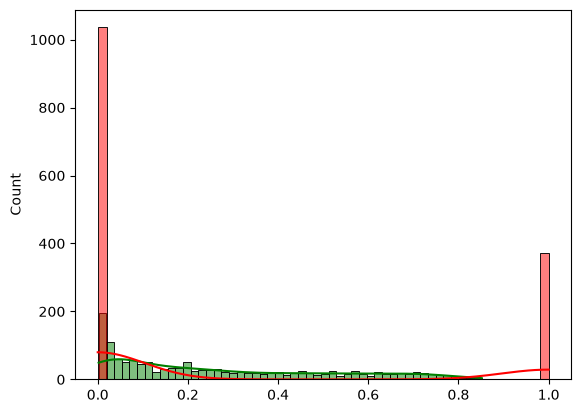

In [127]:
sns.histplot(y_pred, kde=True, bins=50, color='green', label='y_pred')
sns.histplot(y_test, kde=True, bins=50, color='red', label='y_test')